In [1]:
%load_ext autoreload
%autoreload 2
import warnings
from pprint import pprint
from qiskit_metal import designs
from qiskit_metal import MetalGUI, Dict

from qiskit_metal.analyses.quantization import EPRanalysis
from qiskit_metal.qlibrary.user_components.JJ_Array import JJ_Array
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder

warnings.filterwarnings('ignore')

# Open GUI

In [2]:
design = designs.DesignPlanar()
design.overwrite_enabled = True
design.chips.main.material = 'silicon'
gui = MetalGUI(design)

# Make design

In [16]:
design.delete_all_components()

fast_mode = True
gap = 20
separation = 14
N_JJs_bottom = 50
N_JJs_top = 65
junction_width = 1.6 #um
junction_length = 1.1/2 #um
Lj = 2.83  # nH
Cj = 32.65  # fF

junction_length_top = junction_length * N_JJs_top if fast_mode else junction_length
junction_length_bottom = junction_length * N_JJs_bottom if fast_mode else junction_length
Lj_eff_top = Lj * N_JJs_top if fast_mode else Lj
Lj_eff_bottom = Lj * N_JJs_bottom if fast_mode else Lj


options_weak_link = Dict(   
    N = '1',   
    pos_x='-1.5um',
    pos_y=str(-separation/2) + 'um',            
    orientation='horizontal',  
    junction_length='3um',     
    junction_width='1.6um',     
    spacing='0um',             
    Cj='1fF',                  
    Lj='40nH',                  
)

options_bottom_left = Dict(
    orientation='horizontal',  
    junction_length=str(junction_length_bottom) + 'um',     
    junction_width=str(junction_width) + 'um',     
    spacing='0um',             
    # Cj=str(Cj) + 'fF',                  
    Lj=str(Lj_eff_bottom) + 'nH', 
    N=str(1) if fast_mode else str(N_JJs_bottom),
    pos_x=str(-junction_length*N_JJs_bottom - gap/2) + 'um',
    pos_y='-' + str(separation/2) + 'um'
)
options_bottom_right = Dict(
    orientation='horizontal',  
    junction_length=str(junction_length_bottom) + 'um',     
    junction_width=str(junction_width) + 'um',     
    spacing='0um',             
    # Cj=str(Cj) + 'fF',                  
    Lj=str(Lj_eff_bottom) + 'nH', 
    N=str(1) if fast_mode else str(N_JJs_bottom),
    pos_x=str(gap/2) + 'um',
    pos_y='-' + str(separation/2) + 'um'
)

options_top_left = Dict(
    orientation='horizontal',  
    junction_length=str(junction_length_top) + 'um',     
    junction_width=str(junction_width) + 'um',     
    spacing='0um',             
    # Cj=str(Cj) + 'fF',                  
    Lj=str(Lj_eff_top) + 'nH', 
    N=str(1) if fast_mode else str(N_JJs_top),
    pos_x=str(-gap/2 - junction_length*N_JJs_bottom) + 'um',
    pos_y=str(separation/2) + 'um',
)

options_top_right = Dict(
    orientation='horizontal',  
    junction_length=str(junction_length_top) + 'um',     
    junction_width=str(junction_width) + 'um',     
    spacing='0um',             
    # Cj=str(Cj) + 'fF',                  
    Lj=str(Lj_eff_top) + 'nH', 
    N=str(1) if fast_mode else str(N_JJs_top),
    pos_x=str(gap/2 - junction_length*(N_JJs_top - N_JJs_bottom)) + 'um',
    pos_y=str(separation/2) + 'um',
)

# Crear el array
jj_array_bottom_left = JJ_Array(design, 'jj_array_bottom_left', options=options_bottom_left)
jj_array_bottom_right = JJ_Array(design, 'jj_array_bottom_right', options=options_bottom_right)
jj_array_top_left = JJ_Array(design, 'jj_array_top_left', options=options_top_left)
jj_array_top_right = JJ_Array(design, 'jj_array_top_right', options=options_top_right)
weak_link = JJ_Array(design, 'weak_link', options=options_weak_link)

options_route = Dict(
    fillet = '1um',
    lead=Dict(
        start_straight='2um',
    ),
    trace_width = str(junction_width) + 'um', # width of the cable.
)

options_route_left = options_route.copy()
options_route_left.update(
    pin_inputs=Dict(
        start_pin=Dict(component='jj_array_bottom_left', pin='start'),
        end_pin=Dict(component='jj_array_top_left', pin='start')
    )
)

options_route_right = options_route.copy()
options_route_right.update(
    pin_inputs=Dict(
        start_pin=Dict(component='jj_array_bottom_right', pin='end'),
        end_pin=Dict(component='jj_array_top_right', pin='end')
    )
)

options_top = Dict(
        pin_inputs=Dict(
            start_pin=Dict(
                component='jj_array_top_left',
                pin='end'),
            end_pin=Dict(
                component='jj_array_top_right',
                pin='start')),
        trace_width = str(junction_width) + 'um', # width of the cable.
        )

options_wl_left = Dict(
        pin_inputs=Dict(
            start_pin=Dict(
                component='jj_array_bottom_left',
                pin='end'),
            end_pin=Dict(
                component='weak_link',
                pin='start')),
        trace_width = str(junction_width) + 'um', # width of the cable.
        )

options_wl_right = Dict(
        pin_inputs=Dict(
            start_pin=Dict(
                component='jj_array_bottom_right',
                pin='start'),
            end_pin=Dict(
                component='weak_link',
                pin='end')),
        trace_width = str(junction_width) + 'um', # width of the cable.
        )

RouteStraight(design, 'route_top', options=options_top, type='Route')
RouteStraight(design, 'route_wk_left', options=options_wl_left, type='Route')
RouteStraight(design, 'route_wk_right', options=options_wl_right, type='Route')
RoutePathfinder(design, 'route_left', options_route_left, type='Route')
RoutePathfinder(design, 'route_right', options_route_right, type='Route')


gui.rebuild()
gui.autoscale()
all_components = list(design.components.keys())
gui.zoom_on_components(all_components)

# Setup analysis

In [ ]:
jj_array_bottom_left.options['Lj']

{'pos_x': '-37.5um',
 'pos_y': '-7.0um',
 'orientation': 'horizontal',
 'chip': 'main',
 'layer': '1',
 'N': '1',
 'junction_length': '27.500000000000004um',
 'junction_width': '1.6um',
 'spacing': '0um',
 'Cj': '1fF',
 'Lj': '141.5nH',
 'gds_cell_name': '',
 'hfss_mesh_kw_jj': 7e-06,
 'q3d_mesh_kw_jj': 7e-06}

In [ ]:
epr = EPRanalysis(
    design = design,
    renderer_name = "hfss"
    )

# Setup parameters
epr.setup.junctions.jj.rect = 'JJ_rect_Lj_weak_link_jj_0'
epr.setup.junctions.jj.line = 'JJ_Lj_weak_link_jj_0_'

epr.add_junction(name_junction ='inductor_tl')
epr.setup.junctions.inductor_tl = {
    'Lj_variable': 'L_tl',
    'is_junction': False,
    'rect': 'JJ_rect_Lj_jj_array_top_left_jj_0',
    'line': 'JJ_Lj_jj_array_top_left_jj_0_'
}
epr.add_junction(name_junction ='inductor_tr')
epr.setup.junctions.inductor_tr = {
    'Lj_variable': 'L_tr',
    'is_junction': False,
    'rect': 'JJ_rect_Lj_jj_array_top_right_jj_0',
    'line': 'JJ_Lj_jj_array_top_right_jj_0_'
}
epr.add_junction(name_junction ='inductor_bl')
epr.setup.junctions.inductor_bl = {
    'Lj_variable': 'L_bl',
    'is_junction': False,
    'rect': 'JJ_rect_Lj_jj_array_bottom_left_jj_0',
    'line': 'JJ_Lj_jj_array_bottom_left_jj_0_'
}
epr.add_junction(name_junction ='inductor_br')
epr.setup.junctions.inductor_br = {
    'Lj_variable': 'L_br',
    'is_junction': False,
    'rect': 'JJ_rect_Lj_jj_array_bottom_right_jj_0',
    'line': 'JJ_Lj_jj_array_bottom_right_jj_0_'
}


# Setup simulation parameters
epr.sim.setup.name = "JJ_Array"
epr.sim.setup.max_passes = 18
epr.sim.setup.min_converged_passes = 2
epr.sim.setup.n_modes = 3
epr.sim.setup.max_delta_f = 0.5 # percentage
epr.sim.setup.min_freq_ghz = 2
epr.sim.setup.vars = {
    'Lj': weak_link.options['Lj'],
    'Cj': weak_link.options['Cj'],
    'L_bl': jj_array_bottom_left.options['Lj'],
    'L_br': jj_array_bottom_left.options['Lj'],
    'L_tl': jj_array_top_left.options['Lj'],
    'L_tr': jj_array_top_right.options['Lj']
    }

pprint(epr.sim.setup)

{'basis_order': 1,
 'max_delta_f': 0.1,
 'max_passes': 18,
 'min_converged': 1,
 'min_converged_passes': 2,
 'min_freq_ghz': 2,
 'min_passes': 1,
 'n_modes': 3,
 'name': 'JJ_Array',
 'pct_refinement': 30,
 'reuse_selected_design': True,
 'reuse_setup': True,
 'vars': {'Cj': '1fF',
          'L_bl': '141.5nH',
          'L_br': '141.5nH',
          'L_tl': '183.95000000000002nH',
          'L_tr': '183.95000000000002nH',
          'Lj': '40nH'}}


In [62]:
pprint(epr.setup)

{'cos_trunc': 8,
 'dissipatives': {'dielectrics_bulk': ['main']},
 'fock_trunc': 7,
 'junctions': {'inductor_bl': {'Lj_variable': 'L_bl',
                               'is_junction': False,
                               'line': 'JJ_Lj_jj_array_bottom_left_jj_0_',
                               'rect': 'JJ_rect_Lj_jj_array_bottom_left_jj_0'},
               'inductor_br': {'Lj_variable': 'L_br',
                               'is_junction': False,
                               'line': 'JJ_Lj_jj_array_bottom_right_jj_0_',
                               'rect': 'JJ_rect_Lj_jj_array_bottom_right_jj_0'},
               'inductor_tl': {'Lj_variable': 'L_tl',
                               'is_junction': False,
                               'line': 'JJ_Lj_jj_array_top_left_jj_0_',
                               'rect': 'JJ_rect_Lj_jj_array_top_left_jj_0'},
               'inductor_tr': {'Lj_variable': 'L_tr',
                               'is_junction': False,
                           

# Render the HFSS design

In [53]:
# Step 1: Initialize the renderer (connect to HFSS)
if not epr.sim.renderer_initialized:
    epr.sim._initialize_renderer()

# Step 2: Render the design (without running analysis)
epr.sim._render(
    name="JJ_Array",
    solution_type='eigenmode',
    selection=all_components,
    vars_to_initialize=epr.sim.setup.vars,
    box_plus_buffer=True
)

INFO 04:39PM [connect_design]: 	Opened active design
	Design:    JJ_Array_hfss [Solution type: Eigenmode]


'JJ_Array_hfss'

# Analyze the design

In [63]:
# Step 3: Run the analysis
epr.sim._analyze()

INFO 04:49PM [get_setup]: 	Opened setup `JJ_Array`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 04:49PM [analyze]: Analyzing setup JJ_Array
04:54PM 18s INFO [get_f_convergence]: Saved convergences to c:\Users\jc269556\Documents\qiskit-metal\tutorials\hfss_eig_f_convergence.csv


In [8]:
# epr.sim.run() # Run without rendering the design
# epr.sim.run(
#     name="JJ_Array_Sim", 
#     components=all_components
# )

INFO 10:15AM [connect_design]: 	Opened active design
	Design:    JJ_Array_Sim_hfss [Solution type: Eigenmode]
INFO 10:16AM [get_setup]: 	Opened setup `JJ_Array`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 10:16AM [analyze]: Analyzing setup JJ_Array
10:17AM 55s INFO [get_f_convergence]: Saved convergences to c:\Users\jc269556\Documents\qiskit-metal\tutorials\hfss_eig_f_convergence.csv


In [13]:
# Modify variables
# epr.sim.renderer.set_variables({'Cj': '12fF', 'Lj': '1.83nH'})

Variables actualizadas correctamente en HFSS


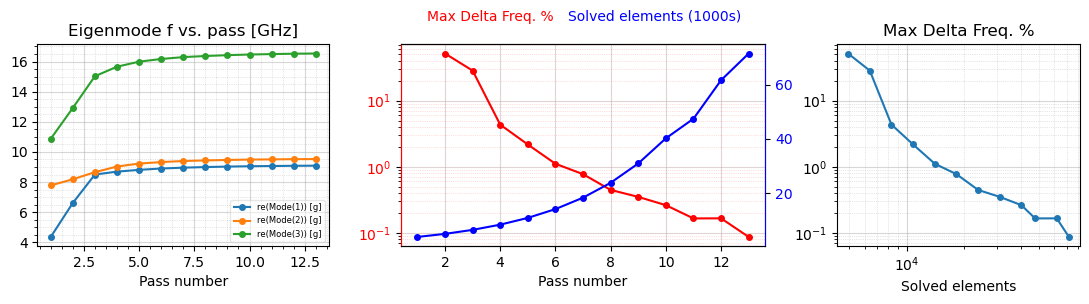

In [64]:
%matplotlib inline
epr.sim.plot_convergences()

In [65]:
epr.sim.convergence_f

,re(Mode(1)) [g],re(Mode(2)) [g],re(Mode(3)) [g]
Pass [],,,
1,4.358974,7.779158,10.870527
2,6.613615,8.186577,12.917101
3,8.499254,8.656196,15.023478
4,8.693363,9.031959,15.655670
5,8.810242,9.228194,15.989747
6,8.900329,9.326164,16.167324
7,8.956401,9.397781,16.292233
8,8.996055,9.437785,16.364976
9,9.027570,9.468439,16.421380


In [31]:
epr.sim.clear_fields()
epr.sim.plot_fields(
    object_name='main',   
    QuantityName="ComplexMag_E",  #ComplexMag_E, ComplexMag_Jsurf, Mesh
    eigenmode=1,  # Mode to plot (from 1 to n)
)

INFO 04:32PM [get_setup]: 	Opened setup `JJ_Array`  (<class 'pyEPR.ansys.HfssEMSetup'>)


In [ ]:
# epr.sim.save_screenshot()

# EPR Analysis

In [66]:
epr.clear_data()
epr.get_stored_energy(False)

Design "JJ_Array_hfss" info:
	# eigenmodes    3
	# variations    1
Design "JJ_Array_hfss" info:
	# eigenmodes    3
	# variations    1

        energy_elec_all       = 1.29691288637788e-27
        energy_elec_substrate = 1.1954031945238e-27
        EPR of substrate = 92.2%

        energy_mag    = 2.40189263905213e-31
        energy_mag % of energy_elec_all  = 0.0%
        


In [67]:
epr.energy_mag / epr.energy_elec

0.00018520076901697876

In [68]:
epr.run_analysis()


Variation 0  [1/1]

  Mode 0 at 9.09 GHz   [1/3]
    Calculating ℰ_magnetic,ℰ_electric
       (ℰ_E-ℰ_H)/ℰ_E       ℰ_E       ℰ_H
              100.0%  6.485e-28 1.201e-31

    Calculating junction energy participation ration (EPR)
	method=`line_voltage`. First estimates:
	junction        EPR p_0j   sign s_0j    (p_capacitive)
		Energy fraction (Lj over Lj&Cj)= 79.31%
	jj              9.26949e-08  (+)        2.41779e-08
		Energy fraction (Lj over Lj&Cj)= 45.46%
	inductor_tl     0.217688  (+)        0.261118
		Energy fraction (Lj over Lj&Cj)= 45.46%
	inductor_tr      0.21737  (+)        0.260736
		Energy fraction (Lj over Lj&Cj)= 52.01%
	inductor_bl     0.229548  (+)        0.211804
		Energy fraction (Lj over Lj&Cj)= 52.01%
	inductor_br     0.229982  (+)        0.212203
		(U_tot_cap-U_tot_ind)/mean=37.00%
Calculating Qdielectric_main for mode 0 (0/2)
p_dielectric_main_0 = 0.92172975307726

  Mode 1 at 9.53 GHz   [2/3]
    Calculating ℰ_magnetic,ℰ_electric
       (ℰ_E-ℰ_H)/ℰ_E       ℰ_E  

04:56PM 25s WARNING [safe_hfss_report_f_convergence]: ANSYS report generation failed (PropServer error). This does not affect EPR analysis results. Skipping convergence plot.



ANALYSIS DONE. Data saved to:

C:\data-pyEPR\Project4\JJ_Array_hfss\2025-11-06 16-55-39.npz




In [60]:
epr.spectrum_analysis(epr.setup.cos_trunc, epr.setup.fock_trunc)

WARNING 04:47PM [__init__]: <p>Error: <class 'IndexError'></p>
ERROR 04:47PM [_get_participation_normalized]: WARNING: U_tot_cap-U_tot_ind / mean = 126.1% is > 15%.                     
Is the simulation converged? Proceed with caution


	 Differences in variations:



 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 
Variation 0

Starting the diagonalization
Finished the diagonalization


ERROR 04:47PM [_get_participation_normalized]: WARNING: U_tot_cap-U_tot_ind / mean = 126.1% is > 15%.                     
Is the simulation converged? Proceed with caution


Pm_norm=
modes
0    2.152961
1    2.074956
2    4.456419
dtype: float64

Pm_norm idx =
      jj  inductor_tl  inductor_tr  inductor_bl  inductor_br
0  False        False        False        False        False
1  False        False        False        False        False
2  False        False        False        False        False
*** P (participation matrix, not normlz.)
             jj  inductor_tl  inductor_tr  inductor_bl  inductor_br
0  1.766821e-08     0.112710     0.113017     0.119436     0.119253
1  6.895211e-02     0.110991     0.110396     0.095891     0.095616
2  3.750676e-06     0.053072     0.053155     0.058636     0.058220

*** S (sign-bit matrix)
   s_jj  s_inductor_tl  s_inductor_tr  s_inductor_bl  s_inductor_br
0    -1             -1              1              1             -1
1     1              1              1              1              1
2    -1              1             -1              1             -1
*** P (participation matrix, normalized.)
   1.8e-08     0